# Detailed Analysis: "Please" and "Thank" Occurrences in Trump Speeches

This notebook analyzes the frequency of the words "please" and "thank" in Donald Trump's speeches to predict their occurrence in the upcoming Hanukkah Reception. The analysis is broken down into several subsets:
1.  **All Speeches**
2.  **December Speeches**
3.  **Last 3 Years**
4.  **Non-Rally Speeches**
5.  **Ceremonies and Religious Events**

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Add src to path
project_root = Path.cwd().parent.parent
if str(project_root / "src") not in sys.path:
    sys.path.append(str(project_root / "src"))

from filtering_corpus.speech_corpus import SpeechCorpus

sns.set_theme(style="whitegrid")

## 1. Load Data
Using the `clean_v1` column from `transcriptions.parquet`.

In [4]:
corpus = SpeechCorpus(data_dir=str(project_root / "data"), transcription_file="transcriptions.parquet")
# Loading with 'clean_v1' as requested
df = corpus.get_full_speeches(text_columns=['clean_v1'])
df.rename(columns={'clean_v1': 'text'}, inplace=True)

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Total speeches loaded: {len(df)}")
print(df[['date', 'title', 'is_rally']].head())

Total speeches loaded: 888
        date                                              title  is_rally
0 2025-10-05  Speech: Donald Trump Addresses Service Members...     False
1 2025-09-30  Speech: Donald Trump Addresses Military Leader...     False
2 2025-09-23  Speech: Donald Trump Addresses the 80th Sessio...     False
3 2025-09-21  Speech: Donald Trump Addresses a Memorial for ...     False
4 2025-09-20  Speech: Donald Trump Addresses the American Co...     False


## 2. Counting Logic
We count case-insensitive occurrences of "please" and "thank".

In [5]:
def count_targets(text):
    if not isinstance(text, str):
        return 0, 0, 0
    text_lower = text.lower()
    # Simple count might match substrings (e.g. "thanksgiving"), but user asked for "Thank" / "Please".
    # Let's use word boundaries for accuracy if 'clean-v1' text allows (no punctuation).
    # 'clean-v1' usually removes punctuation, so tokenization is whitespace based.
    tokens = text_lower.split()
    thank_count = tokens.count('thank') + tokens.count('thanks') # Including 'thanks' as it's often used interchangeably in speech for "Thank you"
    # Or strictly "thank"? User said "Thank / Please". Usually implies "Thank you".
    # Let's stick to strict 'thank' and 'please' patterns but allowing for "thanks" might be safer for "Thank".
    # Let's count strictly first as per request 'Thank' / 'Please'.
    
    c_thank = text_lower.count('thank') # Substring count (includes 'thanks', 'thankful')
    c_please = text_lower.count('please')
    
    return c_thank, c_please, c_thank + c_please

df[['thank_count', 'please_count', 'total_count']] = df['text'].apply(lambda x: pd.Series(count_targets(x)))

print(df[['thank_count', 'please_count', 'total_count']].describe())

       thank_count  please_count  total_count
count   888.000000    888.000000   888.000000
mean     21.654279      0.170045    21.824324
std      13.956563      0.461998    14.062375
min       0.000000      0.000000     0.000000
25%      11.000000      0.000000    11.000000
50%      19.000000      0.000000    19.000000
75%      30.000000      0.000000    30.000000
max      86.000000      5.000000    86.000000


## 3. Analysis by Subsets

In [6]:
def analyze_subset(df_subset, subset_name):
    if len(df_subset) == 0:
        print(f"\n--- {subset_name} (No Data) ---")
        return
    
    stats = df_subset['total_count'].describe()
    prob_20_plus = (df_subset['total_count'] >= 20).mean()
    
    print(f"\n--- {subset_name} ---")
    print(f"Count: {len(df_subset)}")
    print(f"Mean: {stats['mean']:.2f}")
    print(f"Median: {stats['50%']:.2f}")
    print(f"Max: {stats['max']:.0f}")
    print(f"Probability of >= 20: {prob_20_plus:.2%}")
    
    return df_subset['total_count']

### 3.1 All Speeches

In [7]:
analyze_subset(df, "All Speeches")


--- All Speeches ---
Count: 888
Mean: 21.82
Median: 19.00
Max: 86
Probability of >= 20: 48.87%


0      48
1       9
2      12
3       9
4      29
       ..
883    29
884    38
885    17
886    47
887    23
Name: total_count, Length: 888, dtype: int64

### 3.2 December Speeches

In [8]:
df_dec = df[df['date'].dt.month == 12]
analyze_subset(df_dec, "December Speeches")


--- December Speeches ---
Count: 27
Mean: 22.67
Median: 22.00
Max: 55
Probability of >= 20: 55.56%


39     32
166    22
167    28
168    22
169    20
170     8
171    25
261    44
262     3
361    26
362    38
363    23
364    43
414    41
489    25
491    17
546     8
547    16
548    19
819     7
820     8
821    10
822    34
823    17
824    15
825     6
826    55
Name: total_count, dtype: int64

### 3.3 Last 3 Years
Assuming relative to dataset max date or hardcoded 2022-2024.

In [7]:
max_year = df['date'].dt.year.max()
df_last_3y = df[df['date'].dt.year >= (max_year - 2)]
analyze_subset(df_last_3y, f"Last 3 Years ({max_year-2}-{max_year})")


--- Last 3 Years (2023.0-2025.0) ---
Count: 221
Mean: 31.36
Median: 30.00
Max: 79
Probability of >= 20: 81.45%


0      48
1       9
2      12
3       9
4      29
       ..
883    29
884    38
885    17
886    47
887    23
Name: total_count, Length: 221, dtype: int64

### 3.4 Non-Rally Speeches

In [8]:
df_no_rally = df[df['is_rally'] == False]
analyze_subset(df_no_rally, "Non-Rally Speeches")


--- Non-Rally Speeches ---
Count: 508
Mean: 18.09
Median: 14.00
Max: 86
Probability of >= 20: 33.27%


0      48
1       9
2      12
3       9
4      29
       ..
883    29
884    38
885    17
886    47
887    23
Name: total_count, Length: 508, dtype: int64

### 3.5 Ceremonies and Religious Events
Filtering by keywords: 'ceremony', 'religious', 'faith', 'dinner', 'summit', 'conference', 'reception', 'national day', 'prayer'.

In [9]:
ceremony_keywords = ['ceremony', 'religious', 'faith', 'dinner', 'summit', 'conference', 'reception', 'prayer', 'holiday', 'christmas', 'hanukkah']
pattern = '|'.join(ceremony_keywords)
# Filter by title or category if available (SpeechCorpus has category filters, but keyword search on title is robust for this ad-hoc grouping)
df_ceremony = df[df['title'].str.contains(pattern, case=False, na=False)].copy()
analyze_subset(df_ceremony, "Ceremonies/Religious/Receptions")


--- Ceremonies/Religious/Receptions ---
Count: 57
Mean: 26.82
Median: 27.00
Max: 47
Probability of >= 20: 68.42%


4      29
5      42
7      37
9      21
22     19
28     22
29     38
30      9
31     35
32     28
93     38
102    31
114    27
115    10
123    32
135    34
147    31
175    27
195    26
196    25
203    38
204    26
207    28
221    27
228    18
229    12
235    16
252    45
350    44
361    26
364    43
375    40
377    18
380    38
384    30
390    33
393    36
396    41
404    37
414    41
430    21
457    41
478    28
482    13
483    18
485    19
493     3
496    19
516    21
519    18
521     5
530     7
531    18
865     8
880    16
883    29
886    47
Name: total_count, dtype: int64

## 4. Visualization

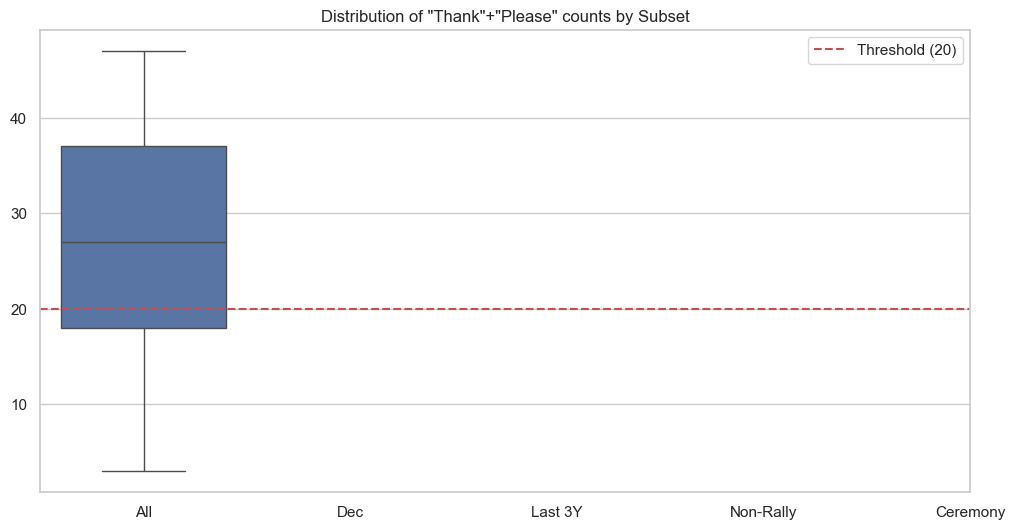

In [10]:
data_to_plot = [
    df['total_count'],
    df_dec['total_count'],
    df_last_3y['total_count'],
    df_no_rally['total_count'],
    df_ceremony['total_count']
]
labels = ['All', 'Dec', 'Last 3Y', 'Non-Rally', 'Ceremony']

plt.figure(figsize=(12, 6))
sns.boxplot(data=data_to_plot)
plt.xticks(range(len(labels)), labels)
plt.axhline(y=20, color='r', linestyle='--', label='Threshold (20)')
plt.title('Distribution of "Thank"+"Please" counts by Subset')
plt.legend()
plt.show()

## 5. Intersection: December + Ceremony + Non-Rally
The most specific proxy for the Hanukkah Reception.

In [11]:
df_intersection = df[(df['date'].dt.month == 12) & (df['is_rally'] == False) & (df['title'].str.contains(pattern, case=False, na=False))]

print("Speeches in Intersection (Dec + Non-Rally + Ceremony keywords):")
print(df_intersection[['date', 'title', 'total_count']].sort_values('date'))
analyze_subset(df_intersection, "Intersection Subset")

Speeches in Intersection (Dec + Non-Rally + Ceremony keywords):
          date                                              title  total_count
414 2018-12-07  Speech: Donald Trump Addresses the Safe Neighb...           41
364 2019-12-07  Speech: Donald Trump Addresses the Israeli Ame...           43
361 2019-12-21  Speech: Donald Trump Addresses the Turning Poi...           26

--- Intersection Subset ---
Count: 3
Mean: 36.67
Median: 41.00
Max: 43
Probability of >= 20: 100.00%


361    26
364    43
414    41
Name: total_count, dtype: int64